In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv(r"M:\data_set\fraudTrain.csv")


print("Train shape:", train_df.shape)


Train shape: (1296675, 23)


In [8]:
print(train_df.info())
print(train_df.describe())
print(train_df.isnull().sum())
print("Duplicates:", train_df.duplicated().sum())

print(train_df["is_fraud"].value_counts())
print(train_df["is_fraud"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

is_fraud – Target variable (1 = Fraud, 0 = Legitimate)

In [9]:
display(train_df.head())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [10]:
list (train_df.columns)

['Unnamed: 0',
 'trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud']

In [11]:

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return 6371 * c


def feature_engineering(df):
    df = df.copy()

    # Convert dates
    df["trans_date_trans_time"] = pd.to_datetime(
        df["trans_date_trans_time"]
    )
    df["dob"] = pd.to_datetime(df["dob"])

    # Transaction time features
    df["trans_hour"] = df["trans_date_trans_time"].dt.hour
    df["trans_day"] = df["trans_date_trans_time"].dt.day
    df["trans_month"] = df["trans_date_trans_time"].dt.month
    df["trans_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek

    # Customer age at transaction time
    df["age"] = (
        (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25
    ).astype(int)

    # Distance between customer and merchant
    df["distance_km"] = haversine(
        df["lat"],
        df["long"],
        df["merch_lat"],
        df["merch_long"]
    )

    return df
train_df = feature_engineering(train_df)


In [12]:
print("Train shape:", train_df.shape)


display(train_df[[
    "trans_hour",
    "trans_day",
    "trans_month",
    "trans_dayofweek",
    "age",
    "distance_km"
]].head(20))

Train shape: (1296675, 29)


,trans_hour,trans_day,trans_month,trans_dayofweek,age,distance_km
0,0,1,1,1,30,78.597568
1,0,1,1,1,40,30.212176
2,0,1,1,1,56,108.206083
3,0,1,1,1,51,95.673231
4,0,1,1,1,32,77.556744
5,0,1,1,1,57,85.922643
6,0,1,1,1,25,118.119776
7,0,1,1,1,71,12.766923
8,0,1,1,1,77,25.270494
9,0,1,1,1,44,74.077750


In [14]:
DROP_COLS = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "dob",
    "first",
    "last",
    "street",
    "city",
    "zip",
    "trans_num",
    "unix_time",

    # Features unavailable from user input
    "cc_num",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long"
]

train_df.drop(columns=DROP_COLS, inplace=True)


In [15]:
print(train_df.columns.tolist())

['merchant', 'category', 'amt', 'gender', 'state', 'job', 'is_fraud', 'trans_hour', 'trans_day', 'trans_month', 'trans_dayofweek', 'age', 'distance_km']


In [16]:
numeric_cols = train_df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_cols.remove("is_fraud")

print(numeric_cols)

['amt', 'trans_hour', 'trans_day', 'trans_month', 'trans_dayofweek', 'age', 'distance_km']


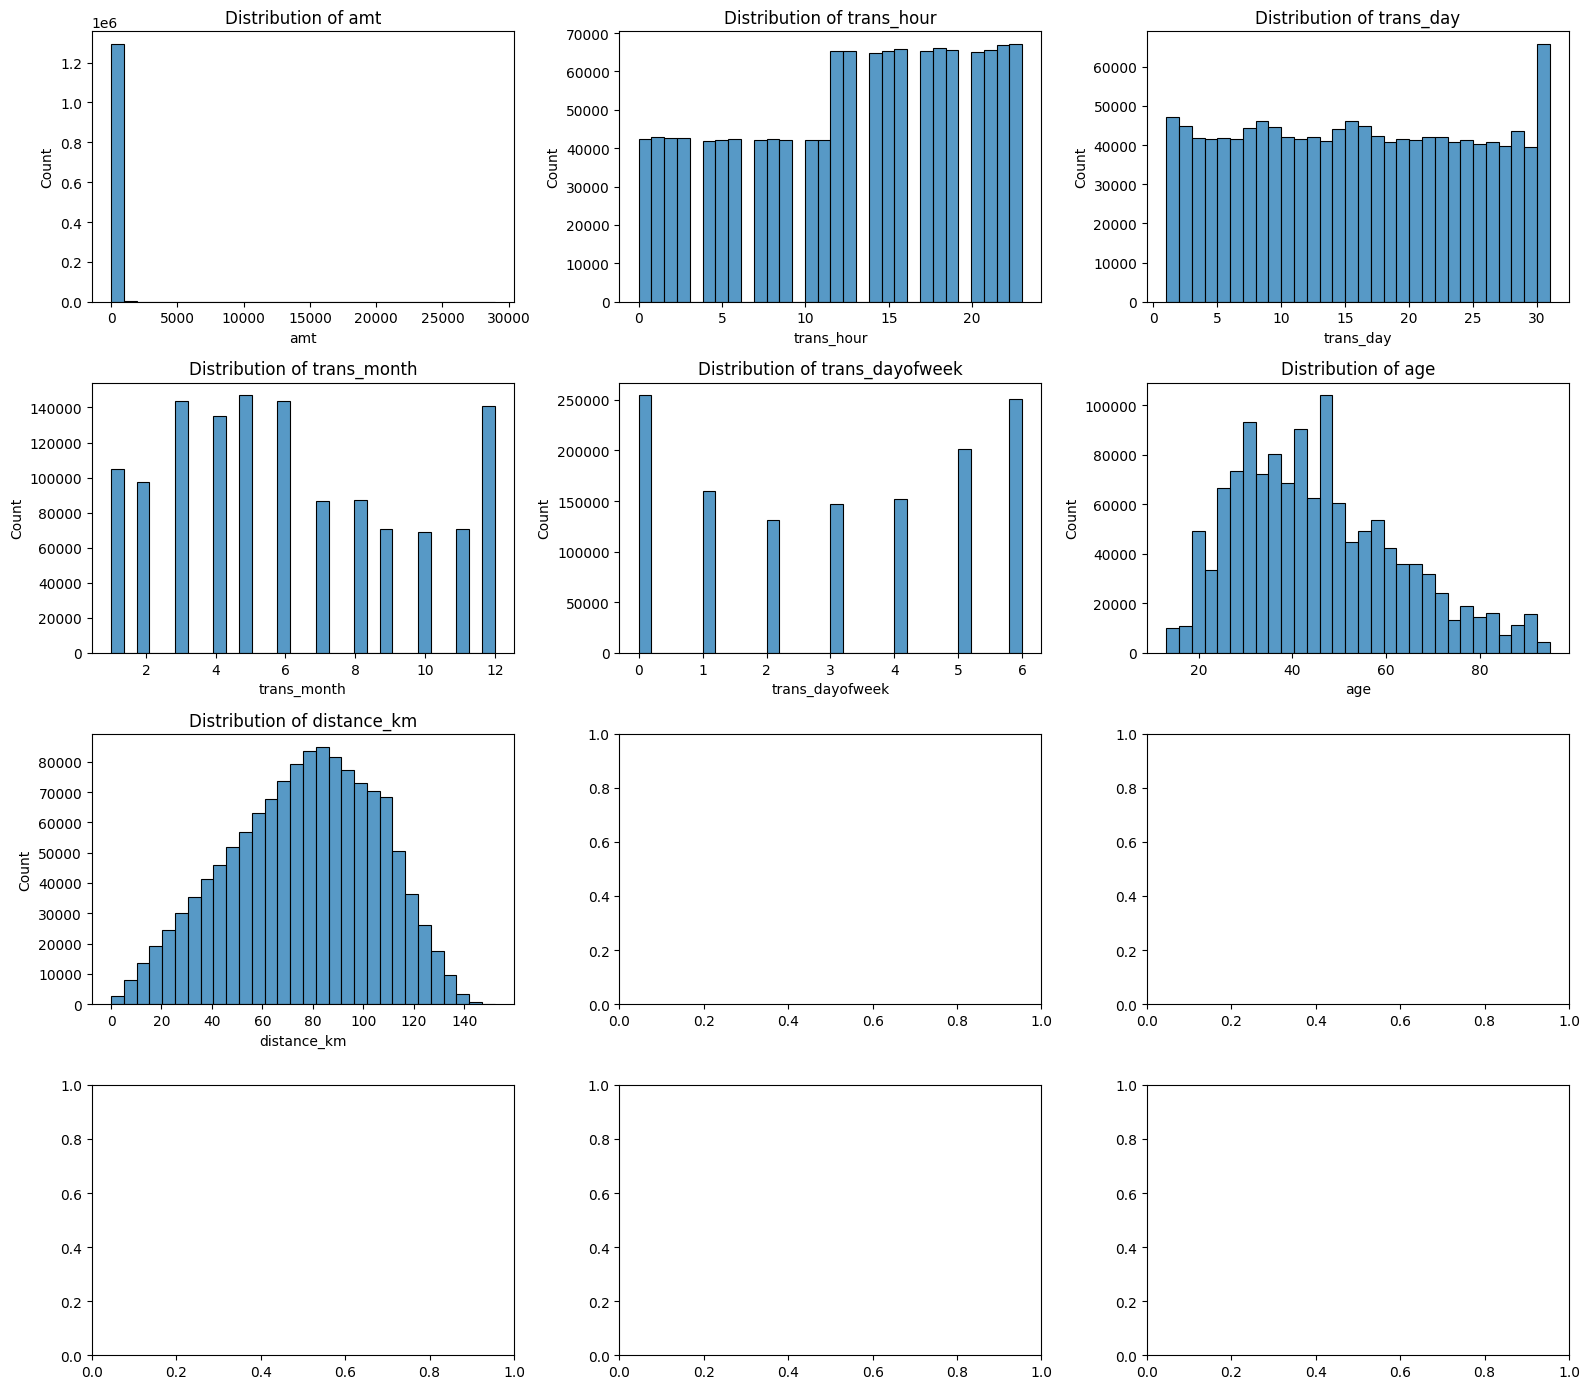

In [17]:

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(
        data=train_df,
        x=col,
       bins=30,
        ax=ax
    )
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

out liers 

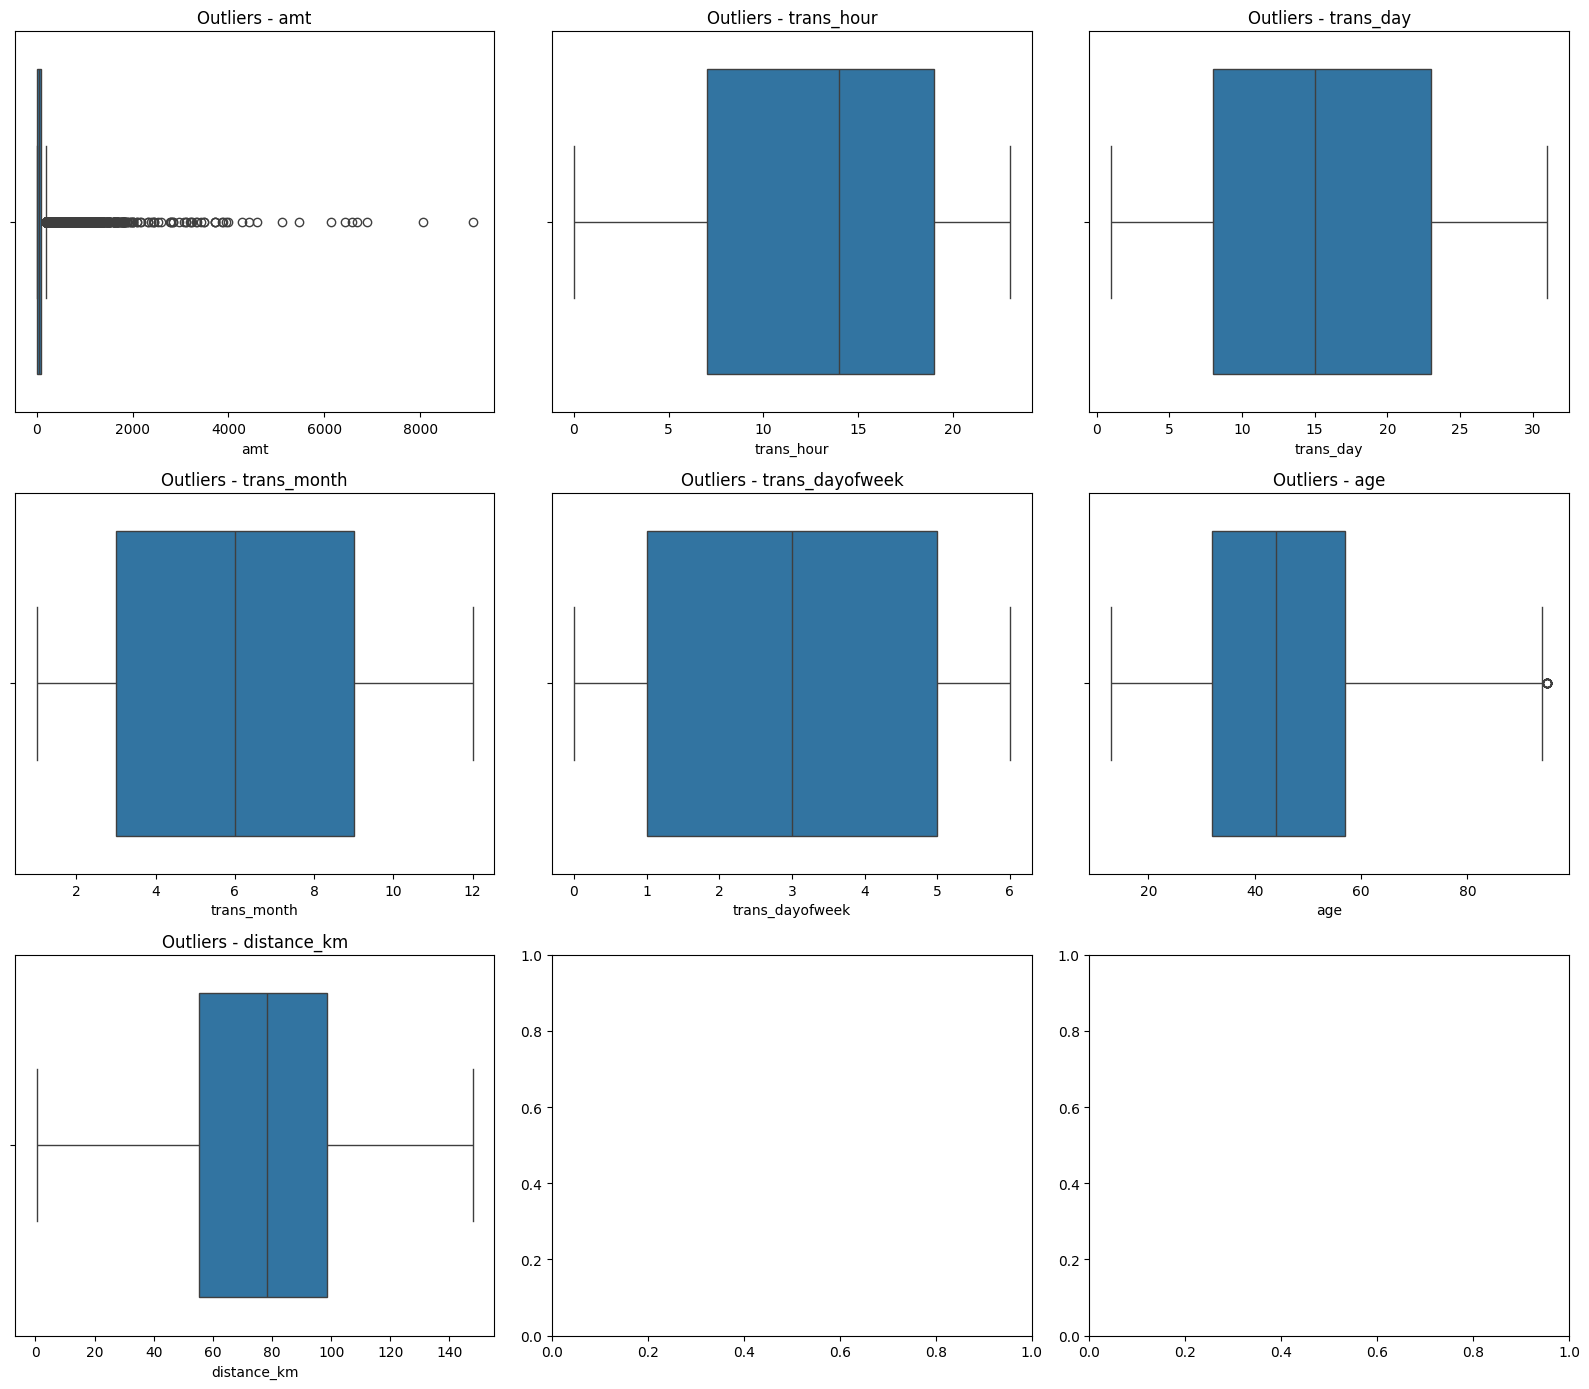

In [19]:
sample_df = train_df.sample(
    n=100000,
    random_state=42
)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(
        data=sample_df,
        x=col,
        ax=ax
    )
    ax.set_title(f"Outliers - {col}")

plt.tight_layout()
plt.show()

In [22]:
print("Age range:")
print(train_df["age"].min(), train_df["age"].max())

print("\nAmount:")
print(train_df["amt"].min(), train_df["amt"].max())





Age range:
13 95

Amount:
1.0 28948.9


In [23]:
print(train_df["is_fraud"].value_counts())

print("\nPercentage:")
print(train_df["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Percentage:
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


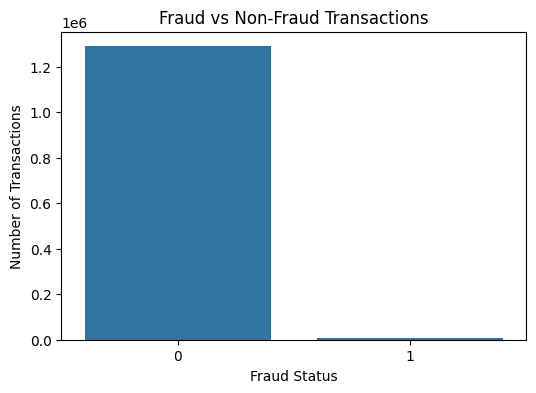

In [24]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=train_df,
    x="is_fraud"
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

plt.show()

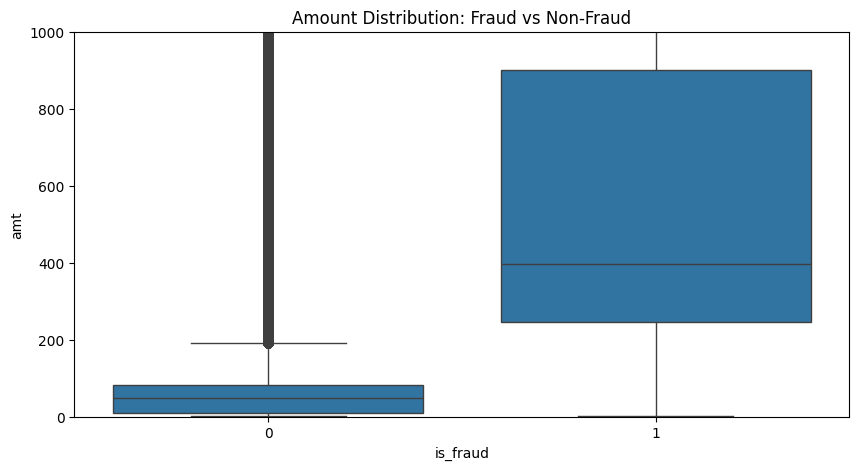

In [25]:
plt.figure(figsize=(10,5))
sns.boxplot(x='is_fraud', y='amt', data=train_df)
plt.title('Amount Distribution: Fraud vs Non-Fraud')
plt.ylim(0, 1000)
plt.show()

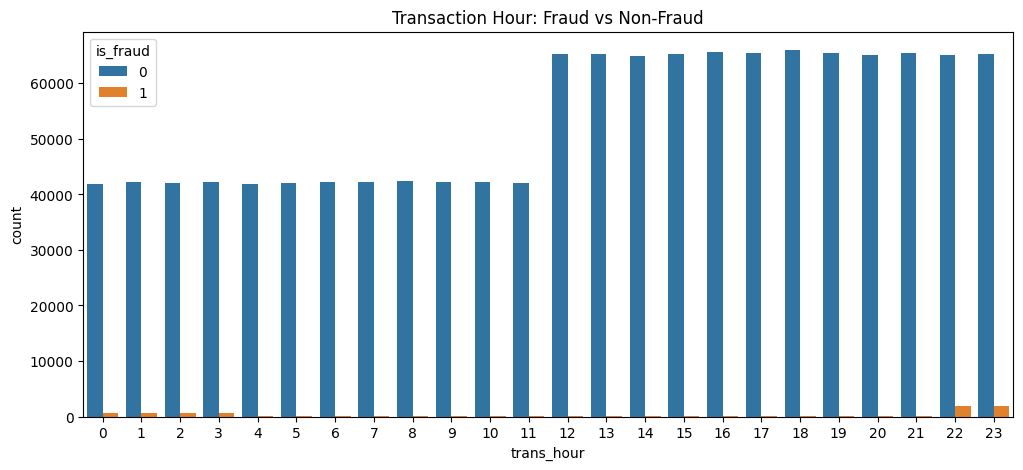

In [26]:
plt.figure(figsize=(12,5))
sns.countplot(x='trans_hour', hue='is_fraud', data=train_df)
plt.title('Transaction Hour: Fraud vs Non-Fraud')
plt.show()

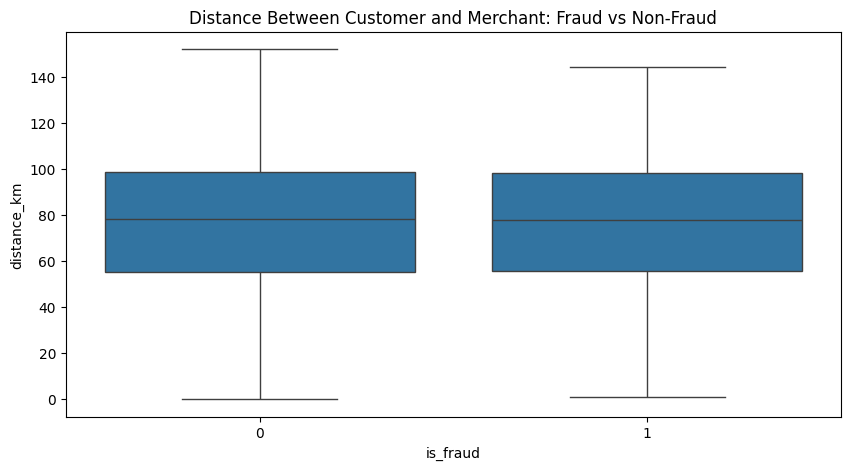

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(x='is_fraud', y='distance_km', data=train_df)
plt.title('Distance Between Customer and Merchant: Fraud vs Non-Fraud')
plt.show()

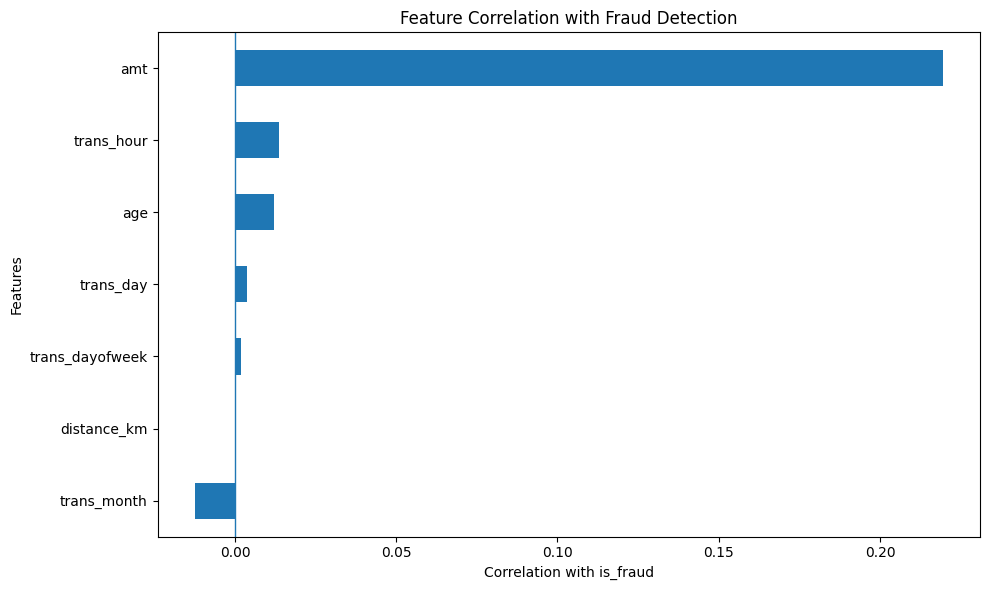

In [28]:
# Correlation of numeric features with fraud
corr_with_fraud = (
    train_df[numeric_cols + ['is_fraud']]
    .corr()['is_fraud']
    .drop('is_fraud')
    .sort_values()
)

plt.figure(figsize=(10, 6))

corr_with_fraud.plot(kind='barh')

plt.title('Feature Correlation with Fraud Detection')
plt.xlabel('Correlation with is_fraud')
plt.ylabel('Features')

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

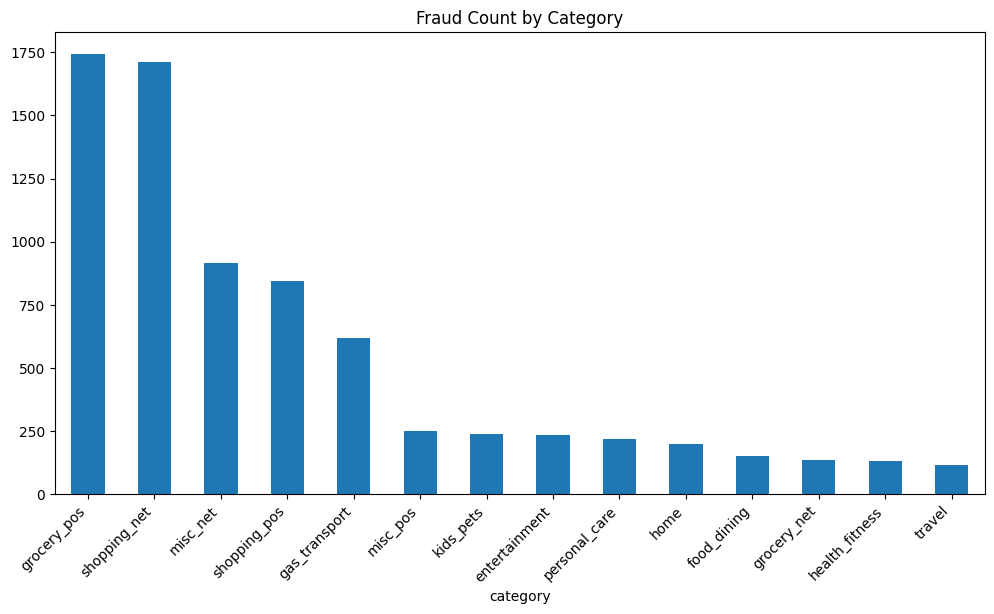

In [29]:

plt.figure(figsize=(12,6))
fraud_by_category = train_df[train_df['is_fraud']==1]['category'].value_counts()
fraud_by_category.plot(kind='bar')
plt.title('Fraud Count by Category')
plt.xticks(rotation=45, ha='right')
plt.show()

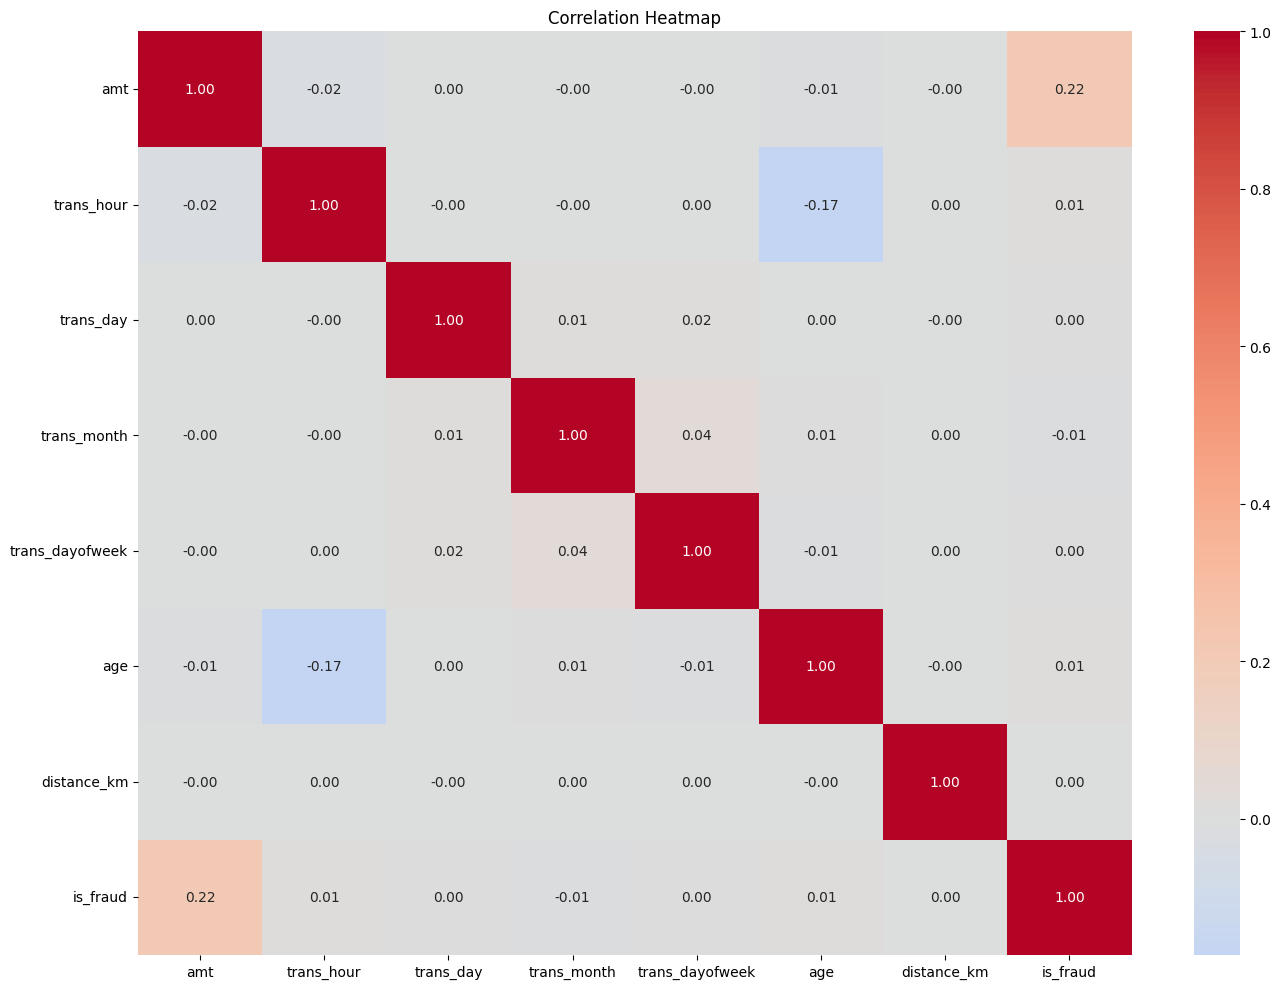

In [30]:
plt.figure(figsize=(14, 10))

corr = train_df[numeric_cols + ['is_fraud']].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 8. Train-Test Split

The dataset is split into training and testing sets to evaluate the model on unseen data.

- 80% of the data is used for training.
- 20% of the data is used for testing.
- `stratify=y` preserves the original fraud/non-fraud class distribution.
- `random_state=42` ensures reproducible results.

In [31]:
from sklearn.model_selection import train_test_split

x= train_df.drop('is_fraud', axis=1)
y = train_df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [32]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1037340, 12)
X_test: (259335, 12)
y_train: (1037340,)
y_test: (259335,)


ENCODING CATEGORAL DATA AFTER SPLITTING 

In [33]:
categorical_cols =train_df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"{col}: {train_df[col].nunique()} unique values")

merchant: 693 unique values
category: 14 unique values
gender: 2 unique values
state: 51 unique values
job: 494 unique values


In [34]:
binary_cols = ['gender']

onehot_cols = ['category', 'state']

frequency_cols = ['merchant', 'job']

In [35]:
print(train_df['gender'].unique())

['F' 'M']


In [36]:
X_train['gender'] = train_df.loc[X_train.index, 'gender']
X_test['gender'] = train_df.loc[X_test.index, 'gender']
print(X_train['gender'].unique())

['F' 'M']


In [37]:
X_train['gender'] = X_train['gender'].map({'F': 0, 'M': 1})
X_test['gender'] = X_test['gender'].map({'F': 0, 'M': 1})

In [38]:
print(X_train['gender'].unique())
print(X_test['gender'].unique())

print("Train NaN:", X_train['gender'].isna().sum())
print("Test NaN:", X_test['gender'].isna().sum())

[0 1]
[0 1]
Train NaN: 0
Test NaN: 0


In [39]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_ohe = ohe.fit_transform(X_train[onehot_cols])
X_test_ohe = ohe.transform(X_test[onehot_cols])
ohe_columns = ohe.get_feature_names_out(onehot_cols)

X_train_ohe = pd.DataFrame(
    X_train_ohe,
    columns=ohe_columns,
    index=X_train.index
)

X_test_ohe = pd.DataFrame(
    X_test_ohe,
    columns=ohe_columns,
    index=X_test.index
)
print(X_train_ohe.shape)
print(X_test_ohe.shape)

X_train_ohe.head()

(1037340, 65)
(259335, 65)


,category_entertainment,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,...,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
509059,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
395295,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536531,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
271001,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
532788,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
frequency_cols = ['merchant', 'job']

for col in frequency_cols:
    freq = X_train[col].value_counts(normalize=True)

    X_train[col + '_freq'] = X_train[col].map(freq)
    X_test[col + '_freq'] = X_test[col].map(freq).fillna(0)
display(X_train[['merchant_freq', 'job_freq']].head())
display(X_test[['merchant_freq', 'job_freq']].head())

,merchant_freq,job_freq
509059,0.000696,0.005535
395295,0.001402,0.002358
536531,0.001768,0.002784
271001,0.001326,0.000799
532788,0.001411,0.006703


,merchant_freq,job_freq
1161537,0.000988,0.004717
192923,0.002018,0.002298
1086283,0.001952,0.000426
1069482,0.002081,0.002409
689806,0.001850,0.004059


In [41]:
X_train_final = pd.concat([
    X_train[numeric_cols + ['gender', 'merchant_freq', 'job_freq']],
    X_train_ohe
], axis=1)

X_test_final = pd.concat([
    X_test[numeric_cols + ['gender', 'merchant_freq', 'job_freq']],
    X_test_ohe
], axis=1)
print("X_train_final:", X_train_final.shape)
print("X_test_final:", X_test_final.shape)

X_train_final: (1037340, 75)
X_test_final: (259335, 75)


In [42]:
print(X_train_final.isnull().sum().sum())
print(X_test_final.isnull().sum().sum())

0
0


In [44]:
train_encoded = X_train_final.copy()
train_encoded['is_fraud'] = y_train.values

test_encoded = X_test_final.copy()
test_encoded['is_fraud'] = y_test.values

train_encoded.to_parquet("train_encoded.parquet", index=False)
test_encoded.to_parquet("test_encoded.parquet", index=False)